In [1]:
import sys
sys.path.append('../')


from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
import sigmaX_fidelity_optimize as zpX
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy as sp
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
from IPython.display import display, Math

import networkx as nx

# Initialize Hilbert Space

In [2]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)

phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
trunc1 = 30
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=trunc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=trunc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=trunc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=trunc1)
H0 = qt.Qobj(np.diag(evals))

w_trans_1 = {}
w_trans_2 = {}
core_states = {}
drive_term = {}

w_trans_1["phi"] = evals[9] - evals[0]
w_trans_2["phi"] = evals[9] - evals[2]
drive_term["phi"] = n_Phi
core_states["phi"] = [0, 2, 9]

w_trans_1["theta"] = evals[7] - evals[0]
w_trans_2["theta"] = evals[7] - evals[2]
drive_term["theta"] = n_Theta
core_states["theta"] = [0, 2, 7]

# Truncation Estimate

To estimate which transitions should be the most important, we can calculate a generalized rabi frequency for each transition

$$
\Omega_{ij} = \frac{(A n_{ij})^2}{(A n_{ij})^2 + \delta^2}
$$

where $A$ is the amplitude of the control pulse and $n_{ij} = \langle i | n | j \rangle$ is the drive matrix. $\delta$ is the detuning between the drive and the transition $\omega_d - \omega_{ij}$.


In [3]:
drives = ["phi", "theta"]
rabi_df = {}
rabi_freq = {}
A = 1
for drive in drives:
    rabi_freq[drive] = np.zeros((evals.size, evals.size))
    rabi_df[drive] = []
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            n_ij = np.abs(drive_term[drive][i, j])
            # Assume very close to resonance driving -- not actually true
            delta = -0.001
            delta1 = abs(abs(w_trans_1[drive]) - abs(evals[i] - evals[j]) - delta)
            delta2 = abs(abs(w_trans_2[drive]) - abs(evals[i] - evals[j]) - delta)
            delta = min(delta1, delta2)
            Omega_ij = ((A*n_ij)**2) / ((A*n_ij)**2 + delta**2)

            rabi_freq[drive][i, j] = Omega_ij
            rabi_df[drive].append({"ij": f"{i}_{j}", "i": i, "j": j, "rabi": Omega_ij, "drive": drive})
    rabi_df[drive] = pd.DataFrame(rabi_df[drive])
    rabi_df[drive].index = rabi_df[drive]["ij"]

In [4]:
print("fraction of 0 rabi freq",
      "theta:", sum(rabi_df["theta"]["rabi"] == 0)/rabi_df["theta"].shape[0],
      "phi:", sum(rabi_df["phi"]["rabi"] == 0)/rabi_df["phi"].shape[0])

fraction of 0 rabi freq theta: 0.6942528735632184 phi: 0.7218390804597701


Now for each transition try to calculate the ``distance'' from the logical or intermediate states. Here I define that as the product of the rabi frequencies that get you there. To calculate that, use a graph where the nodes are the rows/columns and the weights on each edge are:

$$
W_{ij} = -\log(\Omega_{ij})
$$

Note that the edge is only added if $\Omega_{ij} > 0$. We can then use graph search algorithms to find the shortest path.

In [5]:
# Construct the graph
rabi_graph = {}
for drive in drives:
    rabi_graph[drive] = nx.Graph()
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            Omega_ij = rabi_freq[drive][i,j]
            if Omega_ij > 0:
                rabi_graph[drive].add_edge(i, j, weight=-np.log(Omega_ij))  # specify edge data

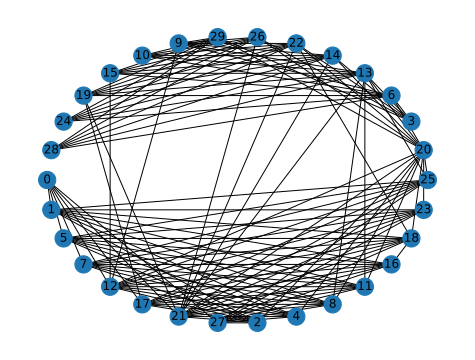

In [23]:
G = rabi_graph['theta']
nx.draw(G, pos=nx.shell_layout(G), with_labels=True)

In [6]:
drive = "theta"
(i, j) = (3, 5)
shortest_path = ""
shortest_path_len = np.inf
for source in core_states[drive]:
        for target in (i, j):
            if source == target:
                continue
            path = nx.shortest_path(rabi_graph[drive],
                                    source=source, target=target,
                                    weight="weight")
            path_len = nx.shortest_path_length(rabi_graph[drive],
                                                source=source, target=target,
                                                weight="weight")
            # Only consider paths where the last two in the path are
            # the states being considered in this transition
            # if i in path[-2:] and j in path[-2:] and path_len < shortest_path_len:
            if path_len < shortest_path_len:
                shortest_path_len = path_len
                shortest_path = ",".join([str(x) for x in path])

shortest_path, shortest_path_len

('7,11,5', 0.5684068861276054)

In [7]:
def shortest_path_to_core(row):
    shortest_path = ""
    shortest_path_len = np.inf
    drive = row["drive"]
    i = row["i"]
    j = row["j"]
    for source in core_states[drive]:
        for target in (i, j):
            path = nx.shortest_path(rabi_graph[drive],
                                    source=source, target=target,
                                    weight="weight")
            path_len = nx.shortest_path_length(rabi_graph[drive],
                                                source=source, target=target,
                                                weight="weight")
            # Only consider paths where the last two in the path are
            # the states being considered in this transition
            # if i in path[-2:] and j in path[-2:] and path_len < shortest_path_len:
            if path_len < shortest_path_len:
                shortest_path_len = path_len
                shortest_path = ",".join([str(x) for x in path])
    return shortest_path_len, shortest_path

# Find shortest path for every row of the dataframe
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=False, nb_workers=10)


INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [8]:
res = {}
for drive in ["theta", "phi"]:
    res[drive] = rabi_df[drive].parallel_apply(shortest_path_to_core, axis=1)

In [9]:
rabi_df['theta']

,ij,i,j,rabi,drive
ij,,,,,
0_1,0_1,0,1,0.596396,theta
0_2,0_2,0,2,0.000000,theta
0_3,0_3,0,3,0.000000,theta
0_4,0_4,0,4,0.000000,theta
0_5,0_5,0,5,0.000159,theta
...,...,...,...,...,...
26_28,26_28,26,28,0.248643,theta
26_29,26_29,26,29,0.000000,theta
27_28,27_28,27,28,0.000000,theta


In [17]:
rabi_df['theta']

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
0_1,0_1,0,1,0.596396,theta,0,1.000000e+00,5.963963e-01,1,1
0_2,0_2,0,2,0.000000,theta,0,1.000000e+00,0.000000e+00,1,-1
0_3,0_3,0,3,0.000000,theta,0,1.000000e+00,0.000000e+00,1,3
0_4,0_4,0,4,0.000000,theta,0,1.000000e+00,0.000000e+00,1,4
0_5,0_5,0,5,0.000159,theta,0,1.000000e+00,1.587744e-04,1,5
...,...,...,...,...,...,...,...,...,...,...
26_28,26_28,26,28,0.248643,theta,"7,11,21,13,28",1.529604e-24,3.803251e-25,5,11
26_29,26_29,26,29,0.000000,theta,"7,11,21,13,20,26",1.443250e-24,0.000000e+00,6,11
27_28,27_28,27,28,0.000000,theta,"7,25,27",2.344820e-01,0.000000e+00,3,25


In [ ]:
for drive in drives:
    rabi_df[drive]["path"] = ""
    rabi_df[drive]["path_len"] = 0.0
    rabi_df[drive]["score"] = 0.0
    rabi_df[drive]["degree"] = -1
    rabi_df[drive]["first_leakage"] = -1
    for ij in rabi_df[drive]["ij"].values:
        if res[drive][ij][1] != "":
            rabi_df[drive].at[ij, "path"] = res[drive][ij][1]
            rabi_df[drive].at[ij, "path_len"] = np.exp(-res[drive][ij][0])
            rabi_df[drive].at[ij, "score"] = np.exp(-res[drive][ij][0]) * rabi_df[drive].at[ij, "rabi"]
            rabi_df[drive].at[ij, "degree"] = res[drive][ij][1].count(",") + 1
            path = res[drive][ij][1].split(",")
            if path[-1] == ij[0]:
                path.append(ij[-1])
            else:
                path.append(ij[0])
            leakage_states = [x for x in path if int(x) not in core_states[drive]]
            if leakage_states:
                rabi_df[drive].at[ij, "first_leakage"] = int(leakage_states[0])
            else:
                rabi_df[drive].at[ij, "first_leakage"] = -1


# 

# States to keep

to try and estimate states to keep

In [ ]:
contrib = {}
for drive in ['theta']:
    contrib[drive] = {}
    print(contrib)
    # for row in rabi_df[drive].iterrows():
    for row in [rabi_df[drive].iloc[0]]:
        print(row)
        for key in ["i", "j"]:
            if row[key] not in contrib[drive]:
                print(contrib)
                contrib[drive][row[key]] = row.score
            else:
                if contrib[drive][row[key]] < row.score:
                    contrib[drive][row[key]] = row.score
print(contrib)

{'theta': {}}
ij                    0_1
i                       0
j                       1
rabi             0.596396
drive               theta
path                    0
path_len              1.0
score            0.596396
degree                  1
first_leakage           1
Name: 0_1, dtype: object
{'theta': {}}
{'theta': {0: 0.5963963186897433}}
{'theta': {0: 0.5963963186897433, 1: 0.5963963186897433}}


In [19]:
contrib = {}
for drive in drives:
    contrib[drive] = {}
    for _, row in rabi_df[drive].iterrows():
        for key in ["i", "j"]:
            if row[key] not in contrib[drive]:
                contrib[drive][row[key]] = row.score
            else:
                if contrib[drive][row[key]] < row.score:
                    contrib[drive][row[key]] = row.score

In [20]:
order_to_keep = {}
sorted_contrib = {}
for drive in drives:
    sorted_contrib[drive] = sorted(contrib[drive].items(), key=lambda item: item[1], reverse=True)
    order_to_keep[drive] = [x[0] for x in sorted_contrib[drive]]
sorted_contrib["theta"][:30]

[(2, 0.9999993043136401),
 (7, 0.9999993043136401),
 (0, 0.9999907208230588),
 (4, 0.6567955331350365),
 (25, 0.6565964206733375),
 (1, 0.5963963186897433),
 (11, 0.5807868981313496),
 (5, 0.5664271031574966),
 (12, 0.5549922155570575),
 (23, 0.4628884878616937),
 (8, 0.27113988595728256),
 (27, 0.23448201473345223),
 (17, 0.23001186156203077),
 (21, 0.1931156190534526),
 (18, 0.12298066453510619),
 (16, 0.05780539203544256),
 (13, 1.6631458909579933e-23),
 (20, 1.6030531089958824e-23),
 (22, 7.92177927648509e-24),
 (9, 7.723068155133693e-24),
 (6, 4.7764933783685944e-24),
 (14, 4.09016551907747e-24),
 (15, 3.0452474632683224e-24),
 (3, 2.6956652841880323e-24),
 (28, 1.5296042749151021e-24),
 (26, 1.4432497533995428e-24),
 (10, 1.3256058632311254e-24),
 (19, 8.825013778836744e-25),
 (29, 4.29803129234494e-25),
 (24, 3.6989506536225923e-25)]

## Also sort by matrix element for comparison

In [12]:
max_vals = {}
order_charge = {}
for drive in drives:
    max_vals[drive] = {}
    for i in range(trunc1):
        if i not in core_states[drive][:-1]:
            max_vals[drive][i] = max([np.abs(drive_term[drive][s, i]/(2*np.pi)) for s in core_states[drive]])

    max_vals[drive] = sorted(max_vals[drive].items(), key=lambda item: item[1], reverse=True)
    order_charge[drive] = [x[0] for x in max_vals[drive]]

max_vals["theta"][:20]


[(4, 1.9963805986677123),
 (8, 1.680931890286884),
 (11, 1.5471327505855181),
 (1, 1.3044291547555027),
 (5, 1.2618860950297839),
 (18, 0.5265822185057764),
 (16, 0.21111207838911888),
 (25, 0.20449750128672434),
 (7, 0.19081531840954893),
 (40, 0.1582053737937271),
 (31, 0.14563834037825402),
 (33, 0.11494673356847576),
 (12, 0.09881888394562985),
 (23, 0.09482552134016325),
 (21, 0.09135534829985792),
 (42, 0.08395586032705674),
 (37, 0.08173996465247234),
 (46, 0.0684163781625298),
 (38, 0.0513783053590689),
 (67, 0.050226182245491496)]

## $n_\theta$

In [13]:
rabi_df["theta"].sort_values(by="score", ascending=False).iloc[:30]

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
2_7,2_7,2,7,0.999999,theta,2,1.000000,0.999999,1,-1
0_7,0_7,0,7,0.999991,theta,0,1.000000,0.999991,1,-1
4_7,4_7,4,7,0.656796,theta,7,1.000000,0.656796,1,4
7_25,7_25,7,25,0.656596,theta,7,1.000000,0.656596,1,5
25_38,25_38,25,38,0.999391,theta,"7,25",0.656596,0.656196,2,25
0_1,0_1,0,1,0.596396,theta,0,1.000000,0.596396,1,1
7_11,7_11,7,11,0.580787,theta,7,1.000000,0.580787,1,1
5_11,5_11,5,11,0.975275,theta,"7,11",0.580787,0.566427,2,11
12_25,12_25,12,25,0.845256,theta,"7,25",0.656596,0.554992,2,25


In [14]:
drive="theta"
nx.shortest_path(rabi_graph[drive],
                                    source=7, target=11,
                                    weight="weight"), nx.shortest_path_length(rabi_graph[drive],
                                                        source=7, target=11,
                                                        weight="weight")

([7, 11], 0.5433713740399171)

In [15]:
drive="theta"
nx.shortest_path(rabi_graph[drive],
                                    source=7, target=5,
                                    weight="weight"), nx.shortest_path_length(rabi_graph[drive],
                                                        source=7, target=5,
                                                        weight="weight")

([7, 11, 5], 0.5684068861277636)

In [16]:
rabi_df["theta"][rabi_df["theta"].i==18].sort_values(by="path_len", ascending=False)

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
18_25,18_25,18,25,0.000000e+00,theta,"7,25",0.656596,0.000000e+00,2,25
18_38,18_38,18,38,7.254976e-02,theta,"7,25,38",0.656196,4.760690e-02,3,25
18_23,18_23,18,23,0.000000e+00,theta,"7,25,12,23",0.462888,0.000000e+00,4,25
18_30,18_30,18,30,6.637078e-01,theta,"7,11,30",0.296107,1.965285e-01,3,11
18_32,18_32,18,32,9.986965e-01,theta,"7,11,32",0.251361,2.510331e-01,3,11
...,...,...,...,...,...,...,...,...,...,...
18_122,18_122,18,122,8.758928e-07,theta,"7,11,32,18",0.251033,2.198780e-07,4,11
18_123,18_123,18,123,0.000000e+00,theta,"7,11,32,18",0.251033,0.000000e+00,4,11
18_124,18_124,18,124,3.196361e-08,theta,"7,11,32,18",0.251033,8.023924e-09,4,11


First leakage states

In [17]:
np.unique(rabi_df["theta"]["first_leakage"].values)

array([-1,  1,  3,  4,  5,  6,  8,  9, 11, 25])

States to include

## $n_\phi$

In [19]:
rabi_df["phi"].sort_values(by="path_len", ascending=False).iloc[:30]

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
0_1,0_1,0,1,0.000000e+00,phi,0,1.0,0.000000e+00,1,1
2_206,2_206,2,206,0.000000e+00,phi,2,1.0,0.000000e+00,1,6
2_204,2_204,2,204,0.000000e+00,phi,2,1.0,0.000000e+00,1,4
2_203,2_203,2,203,0.000000e+00,phi,2,1.0,0.000000e+00,1,3
2_202,2_202,2,202,0.000000e+00,phi,2,1.0,0.000000e+00,1,-1
2_201,2_201,2,201,0.000000e+00,phi,2,1.0,0.000000e+00,1,1
2_200,2_200,2,200,5.876607e-12,phi,2,1.0,5.876607e-12,1,-1
2_199,2_199,2,199,0.000000e+00,phi,2,1.0,0.000000e+00,1,-1
2_198,2_198,2,198,2.427959e-11,phi,2,1.0,2.427959e-11,1,8


In [20]:
rabi_df["phi"]["first_leakage"].unique()

array([ 1, -1,  3,  4,  5,  6,  7,  8, 33, 10, 19])

In [21]:
sorted_contrib["phi"] = sorted(contrib["phi"].items(), key=lambda item: item[1], reverse=True)
order_to_keep["phi"] = [x[0] for x in sorted_contrib["phi"]]
sorted_contrib["phi"][:10]

[(0, 0.9999893874876175),
 (9, 0.9999893874876175),
 (2, 0.9999350068102424),
 (33, 0.9468841513046126),
 (55, 0.9461486523319212),
 (69, 0.9342034632274162),
 (92, 0.9208855832160907),
 (126, 0.8651587293417935),
 (76, 0.7765779668107565),
 (46, 0.7763054457489943)]

In [22]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

# Driving to test fidelity

## $n_\theta$

Keeping the first 300 states

In [ ]:
def theta_test_pulse(hilbert_space):
    # tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
    # tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [30, 0.298429, 0.048571, -0.03174, -0.029243]
    tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [60, 0.15042571732968524, 0.04685021908945983, 0.03748943485669252, 0.04001032187908264]
    n_cpu = 150
    argz = [H0, drive_term["theta"], w_trans_1["theta"], w_trans_2["theta"], hilbert_space, n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    return ut.xgate_fidelity(argz)

f_300 = theta_test_pulse(list(np.arange(300)))
f_300

In [ ]:
theta_test_pulse(sorted(set([0,2,7] + order_to_keep[drive][:100])))

Plot keeping the first n states

In [ ]:
first_n_states = [10, 25, 35, 44, 50, 60, 70, 80, 90, 100, 120, 125, 150, 175, 200, 225, 250, 275, 300]
first_n_states = first_n_states
# fid = {}
drive = "theta"
# fid[drive] = {}
# fid[drive]["by_num"] = []
# fid[drive]["by_mat_elem"] = []
fid[drive]["by_estimate"] = []
for n in tqdm(first_n_states):
    # fid[drive]["by_num"].append(theta_test_pulse(list(np.arange(n))))
    # fid[drive]["by_mat_elem"].append(theta_test_pulse(sorted(set(core_states[drive] + order_charge[drive][:n]))))
    fid[drive]["by_estimate"].append(theta_test_pulse(sorted(set(core_states[drive] + order_to_keep[drive][:n]))))

In [ ]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))
for estimate in ["by_num", "by_mat_elem", "by_estimate"]:
    ax[0].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".")
    ax[1].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".")

for i in range(2):
    ax[i].hlines(1-10**(f_300), 0, 300, color="gray", label="300 states", linestyles="--")
    ax[i].set_title("Fidelity")
    ax[i].set_ylabel("Fidelity")
    ax[i].set_xlabel("States Included in Model")
# plt.yscale("log")
ax[1].set_ylim(1-10**(f_300)-0.00025, 1-10**(f_300)+0.00025)
ax[0].set_ylim(1-10**(f_300)-0.01, 1-10**(f_300)+0.01)
plt.tight_layout()
plt.legend();

## Timing Test

In [ ]:
from time import time
def xgate_fidelity_tg_test(argz, just_tg):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    num=100* int(np.max([tg, len(hilbert_space) ]))
    tlist = np.linspace(0, tg, num)  # total time

    if just_tg:
        options =qt.Options(num_cpus=1, nsteps=100*num)
        prop = qt.propagator( H=H_qbt_drive,
                                t=tg,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )  # get the propagator at the final time step
    else:
        options =qt.Options(num_cpus=1)
        prop = qt.propagator( H=H_qbt_drive,
                                t=tlist,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )[-1]  # get the propagator at the final time step
    index_2 = hilbert_space.index(2)
    state_logi = [states[0], states[index_2]]
    Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
            for s2 in state_logi  ])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)

reps = 1
timing_res = {}
for n in [10,50, 100,150]:
    print(n)
    timing_res[n] = {}
    tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
    n_cpu = 10
    argz = [H0, drive_term["theta"], w_trans_1["theta"], w_trans_2["theta"], list(np.arange(n)), n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    for just_tg in [True, False]:
        timing_res[n][just_tg] = []
        for _ in tqdm(range(reps)):
            t0 = time()
            xgate_fidelity_tg_test(argz, just_tg)
            tf = time()
            timing_res[n][just_tg].append(t0-tf)

In [ ]:
timing_res

In [ ]:
y_tlist

In [ ]:
f, ax = plt.subplots()
w = 10
x = np.array(list(timing_res.keys()))
y_t0 = np.array([-timing_res[t][True][0] for t in x])
y_tlist = np.array([-timing_res[t][False][0] for t in x])

# ax.bar(x-w, y_t0, width=w, color='b', align='center', label="Just tg")
# ax.bar(x, y_tlist, width=w, color='g', align='center', label="Full tlist")
ax.plot(x, y_t0, marker=".", color='b', label="Just tg")
ax.plot(x, y_tlist, color='g', marker=".", label="Full tlist")
# ax.plot(x, y_tlist/y_t0, marker=".", color='b', label="Just tg")
plt.ylabel("Time (s)")
plt.xlabel("Number of States")
# plt.yscale("log")
plt.legend();

Compare with Krylov

In [ ]:
sorted([0,2] + order_charge["theta"][:10])

In [ ]:
sorted([0,2] + order_to_keep["theta"][:10])

In [ ]:
[fid["theta"][x] for x in ["by_num", "by_mat_elem", "by_estimate"]]